In [17]:
dataset_folder = '/mnt/Data1/Nick/transcription_pipeline/'

# embryo_datasets = {
#     # 22C embryos Var2, 0.230 um/pixel
#     '001': [
#         'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo01',
#         'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo02',
#         'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo03',
#         'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo04',
#     ],
#
#     # 22C embryos PWM, 0.230 um/pixel
#     '003': [
#         'test_data/NSPARC/2025-05-27/MCP-mSG_His-RFP_RBS(003)_embryo02',
#         'test_data/NSPARC/2025-05-29/MCP-mSG_His-RFP_RBS(003)_embryo01',
#         'test_data/NSPARC/2025-05-29/MCP-mSG_His-RFP_RBS(003)_embryo02',
#     ],
#
#     'test': [
#         'test_data/NSPARC/2025-06-16/MCP-mSG_His-RFP_RBS(001)_embryo02',
#         'test_data/NSPARC/2025-06-16/MCP-mEGFP_His-RFP_RBS(001)_embryo01',
#     ]
# }

# Leica datasets
embryo_datasets = {
    '003': [
        'test_data/2025-03-18/MCP-mSG_His-RFP_RBSPWM(003)_embryo01',
        'test_data/2025-03-18/MCP-mSG_His-RFP_RBSPWM(003)_embryo02',
        # 'test_data/2025-03-18/MCP-mSG_His-RFP_RBSPWM(003)_embryo03',
        'test_data/2025-03-18/MCP-mSG_His-RFP_RBSPWM(003)_embryo04',
        'test_data/2025-03-18/MCP-mSG_His-RFP_RBSPWM(003)_embryo05',
    ],
}

print(embryo_datasets['003'][0])

test_data/2025-03-18/MCP-mSG_His-RFP_RBSPWM(003)_embryo01


Dataset Path: /mnt/Data1/Nick/transcription_pipeline/test_data/2025-03-18/MCP-mSG_His-RFP_RBSPWM(003)_embryo01


/tmp/ipykernel_3272789/949366224.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detected_spots["t_min"] = detected_spots["t_s"] / 60
/tmp/ipykernel_3272789/949366224.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detected_spots["t_bin"] = detected_spots["t_min"].astype(int)


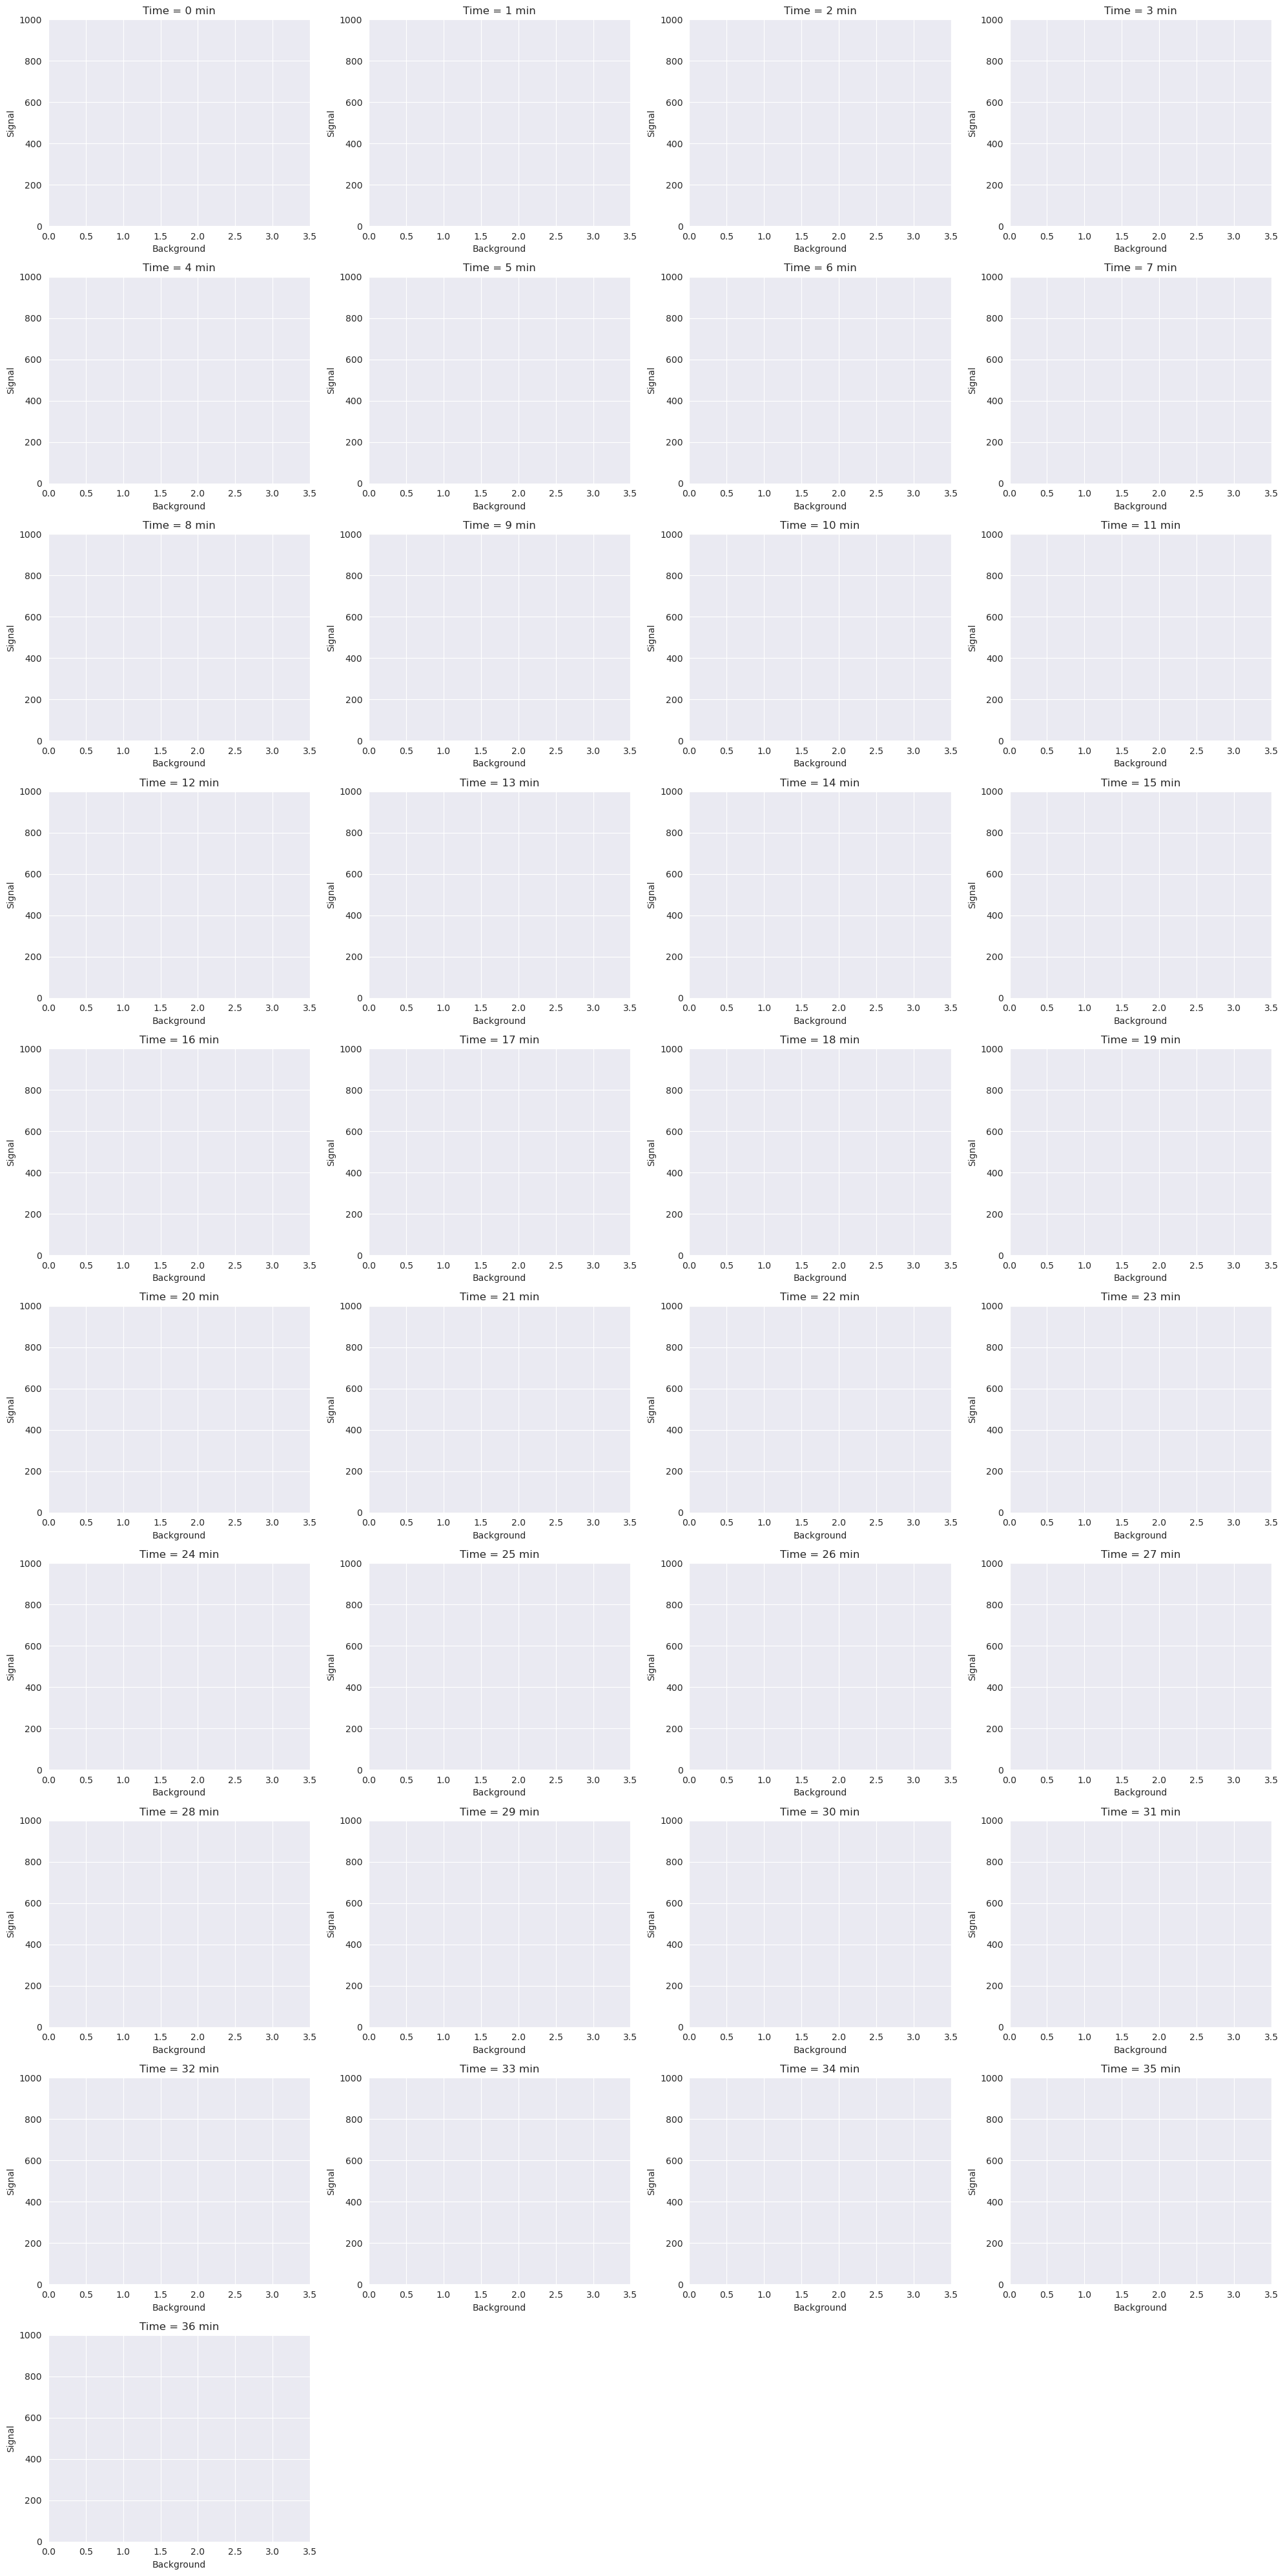

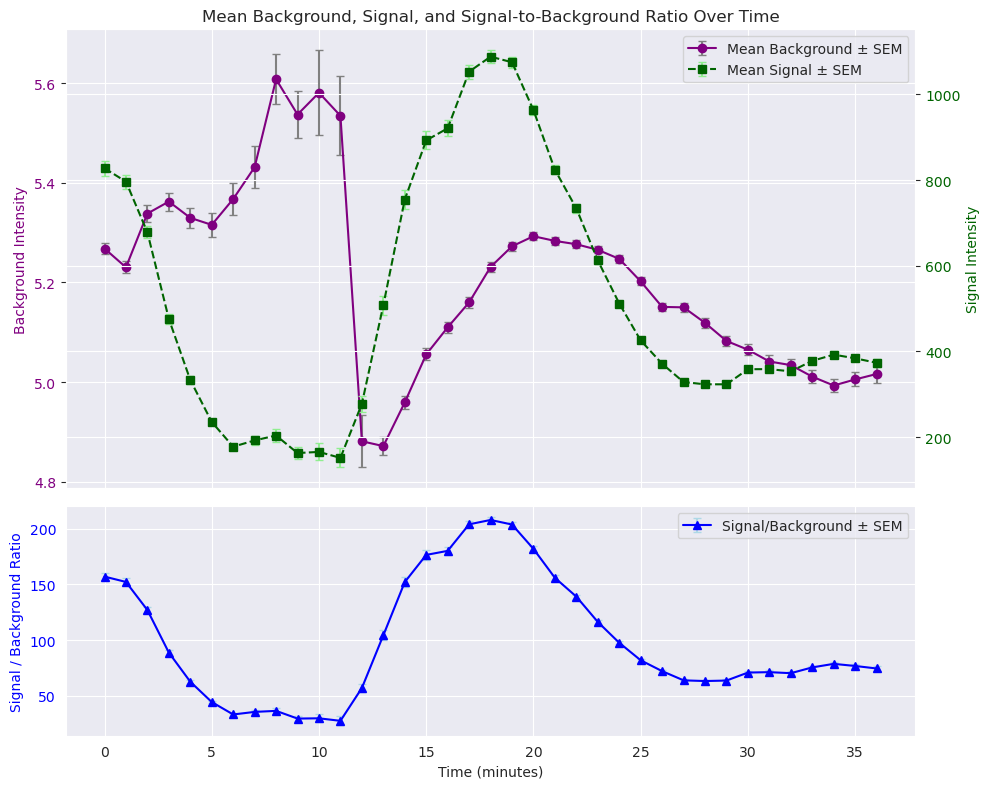

In [18]:
import os
from transcription_pipeline.RateExtraction import FitAndAverage
from transcription_pipeline import spot_pipeline
# from transcription_pipeline import nuclear_pipeline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
import seaborn as sns

# Parameters
nc14_start_frame = 0
min_frames = 40
num_bins = 40

results = []

embryo_id = embryo_datasets['003'][0]
test_dataset_name = os.path.join(dataset_folder, embryo_id)
print('Dataset Path: ' + test_dataset_name)

# --- Load Spot Data ---
spot_tracking = spot_pipeline.Spot()
spot_tracking.read_results(name_folder=test_dataset_name)

spot_df = spot_tracking.spot_dataframe
detected_spots = spot_df[spot_df["particle"] != 0]

# Convert time (t_s) from seconds to minutes
detected_spots["t_min"] = detected_spots["t_s"] / 60
detected_spots["t_bin"] = detected_spots["t_min"].astype(int)

# Group by minute
grouped = detected_spots.groupby("t_bin")

# Plotting
num_plots = len(grouped)
cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

min_points = 50
bins = np.linspace(0, 2.6, 30)  # consistent background range across all plots
bin_centers = (bins[:-1] + bins[1:]) / 2

for i, (minute, group) in enumerate(grouped):
    signal = np.array(group["intensity_from_neighborhood"])
    background = np.array(group["background_intensity_from_neighborhood"])
    digitized = np.digitize(background, bins)

    mean_signal = []
    std_signal = []
    valid_centers = []

    for j in range(1, len(bins)):
        bin_points = signal[digitized == j]
        if len(bin_points) >= min_points:
            mean_signal.append(np.mean(bin_points))
            std_signal.append(np.std(bin_points) / np.sqrt(len(bin_points)))
            valid_centers.append(bin_centers[j - 1])

    ax = axes[i]
    hb = ax.hexbin(background, signal, gridsize=30, cmap='Blues', bins='log')
    ax.plot(valid_centers, mean_signal, 'r-', linewidth=2)
    ax.fill_between(valid_centers,
                    np.array(mean_signal) - np.array(std_signal),
                    np.array(mean_signal) + np.array(std_signal),
                    color='red', alpha=0.2)
    ax.set_xlim(0, 3.5)
    ax.set_ylim(0,1000)
    ax.set_title(f'Time = {minute} min')
    ax.set_xlabel('Background')
    ax.set_ylabel('Signal')

# Hide any extra subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plot_filename = os.path.join(test_dataset_name, f'signal_vs_background_timeSeries.png')
plt.savefig(plot_filename)
plt.show()

# --- Compute stats for signal and background over time ---
avg_background = grouped["background_intensity_from_neighborhood"].mean()
std_background = grouped["background_intensity_from_neighborhood"].std()

avg_signal = grouped["intensity_from_neighborhood"].mean()
std_signal = grouped["intensity_from_neighborhood"].std()

count_per_bin = grouped.size()
sem_background = std_background / np.sqrt(count_per_bin)
sem_signal = std_signal / np.sqrt(count_per_bin)

# --- Compute signal-to-background ratio and its SEM ---
ratio = avg_signal / avg_background
sem_ratio = ratio * np.sqrt((sem_signal / avg_signal)**2 + (sem_background / avg_background)**2)

# --- Plot background and signal with shared gridlines ---
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, height_ratios=[2, 1])

# --- Top plot: Background and Signal ---
# Background (primary axis)
ax1 = ax_top
ax2 = ax1.twinx()

ax1.errorbar(avg_background.index, avg_background, yerr=sem_background,
             fmt='o-', color='purple', ecolor='gray', capsize=3, label='Mean Background ± SEM')
ax1.set_ylabel('Background Intensity', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')
ax1.grid(True)

# Signal (secondary axis)
ax2.errorbar(avg_signal.index, avg_signal, yerr=sem_signal,
             fmt='s--', color='darkgreen', ecolor='lightgreen', capsize=3, label='Mean Signal ± SEM')
ax2.set_ylabel('Signal Intensity', color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')
ax2.set_facecolor('none')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Title
ax1.set_title('Mean Background, Signal, and Signal-to-Background Ratio Over Time')

# --- Bottom plot: Ratio ---
ax_bot.errorbar(ratio.index, ratio, yerr=sem_ratio,
                fmt='^-', color='blue', ecolor='lightblue', capsize=3, label='Signal/Background ± SEM')
ax_bot.set_xlabel('Time (minutes)')
ax_bot.set_ylabel('Signal / Background Ratio', color='blue')
ax_bot.tick_params(axis='y', labelcolor='blue')
ax_bot.grid(True)
ax_bot.legend(loc='upper right')

# Final layout
fig.tight_layout()
plt.show()





In [19]:
detected_spots

,label,z,y,x,frame,t_s,t_frame,raw_spot,coordinates_start,covariance_matrix,...,intensity_from_fit,intensity_std_error_from_fit,intensity_from_neighborhood,intensity_std_error_from_neighborhood,background_intensity_from_neighborhood,background_intensity_std_error_from_neighborhood,nuclear_label,particle,t_min,t_bin
13,233,4.502019,180.812558,322.685290,0,0.840000,0,"[[[4, 9, 4, 4, 7, 9, 4, 3, 10], [8, 9, 4, 4, 5...","[0, 1, 176, 318]","[[0.005976701329273516, 1.4962786533871741e-10...",...,1654.056059,93.907417,1423.052299,103.596716,5.962516,0.199749,879,879,0.014000,0
15,237,5.466345,220.208227,194.639783,0,0.840000,0,"[[[3, 4, 9, 13, 7, 10, 5, 4, 1], [4, 5, 10, 9,...","[0, 1, 215, 190]","[[0.008688967492104134, 8.917306402643906e-06,...",...,3183.661565,295.035104,2148.134312,131.552027,6.466150,0.249148,912,912,0.014000,0
16,246,5.982416,27.298877,650.133427,0,1.051001,0,"[[[5, 6, 6, 5, 6, 4, 4, 6, 7], [7, 4, 8, 6, 3,...","[0, 2, 22, 645]","[[0.01857632855884817, -1.3923603290413012e-07...",...,381.018552,47.249319,439.465632,84.199719,5.259239,0.183580,633,633,0.017517,0
18,256,5.450214,100.455618,267.414289,0,0.840000,0,"[[[10, 4, 8, 6, 4, 5, 6, 1, 4], [9, 7, 9, 4, 6...","[0, 1, 95, 262]","[[0.006938888041445262, 3.477274842929457e-07,...",...,1363.665575,83.636883,1118.200242,84.981357,5.856758,0.191744,874,874,0.014000,0
19,261,7.074931,151.240033,172.171095,0,1.260000,0,"[[[5, 3, 5, 5, 4, 3, 4, 8, 6], [1, 3, 7, 6, 7,...","[0, 3, 147, 167]","[[0.012460289205209824, -4.821702263575846e-07...",...,2295.768050,186.584734,1829.176809,111.805160,5.276220,0.207028,900,900,0.021000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51170,485,14.699595,128.368525,31.015714,485,2190.878000,491,"[[[7, 6, 8, 5, 4, 4, 9, 1, 7], [6, 8, 3, 3, 8,...","[15, 11, 123, 26]","[[0.020328511889726758, 6.352802078440839e-08,...",...,540.300158,55.872064,543.817077,74.979930,4.833692,0.176139,256,256,36.514633,36
51171,489,15.514192,219.823593,10.284648,485,2191.098000,491,"[[[5, 2, 6, 3, 3, 3, 8, 5, 6], [3, 4, 8, 5, 4,...","[15, 12, 215, 5]","[[0.016927113118695655, 2.0448169158235283e-08...",...,231.787834,27.356191,301.453122,67.306707,4.958140,0.162061,264,264,36.518300,36
51172,490,16.065400,231.930299,115.029268,485,2191.098000,491,"[[[6, 3, 6, 9, 5, 6, 9, 4, 4], [5, 7, 8, 5, 9,...","[15, 12, 227, 110]","[[0.011087440570247844, 3.222694278710568e-08,...",...,681.965953,53.933326,650.115571,72.967585,5.083429,0.174873,242,242,36.518300,36
51173,496,17.362504,5.034875,79.469879,485,2191.306999,491,"[[[4, 5, 4, 10, 8, 6, 10, 12, 6], [6, 8, 4, 2,...","[15, 13, 0, 74]","[[0.054641766720120596, -3.7573590616370407e-0...",...,196.981417,37.193582,71.644148,74.368508,5.940531,0.204571,260,260,36.521783,36


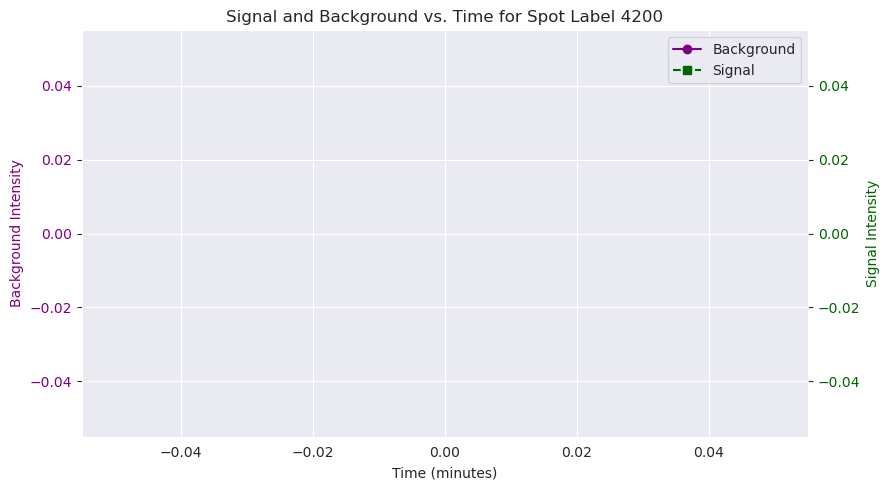

In [20]:
def plot_spot_trace(label_id):
    spot_trace = detected_spots[detected_spots["particle"] == label_id].sort_values("t_min")
    time = spot_trace["t_min"]
    signal = spot_trace["intensity_from_neighborhood"]
    background = spot_trace["background_intensity_from_neighborhood"]

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(time, background, 'o-', color='purple', label='Background')
    ax1.set_xlabel("Time (minutes)")
    ax1.set_ylabel("Background Intensity", color='purple')
    ax1.tick_params(axis='y', labelcolor='purple')
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(time, signal, 's--', color='darkgreen', label='Signal')
    ax2.set_ylabel("Signal Intensity", color='darkgreen')
    ax2.tick_params(axis='y', labelcolor='darkgreen')
    ax2.set_facecolor('none')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.title(f"Signal and Background vs. Time for Spot Label {label_id}")
    fig.tight_layout()
    plt.show()
    plt.close()

# Example usage
plot_spot_trace(4200)
